In [ ]:
import zipfile
import glob
import os

# Find uploaded ZIP file
zip_files = glob.glob("/content/*.zip")

print("ZIP files found:")
for f in zip_files:
    print(f)

# Extract the uploaded ZIP
zip_file = zip_files[0]

with zipfile.ZipFile(zip_file, "r") as z:
    z.extractall("/content/heart_disease")

print("\nDataset extracted successfully!")

# Show extracted files
for root, dirs, files in os.walk("/content/heart_disease"):
    for file in files:
        print(os.path.join(root, file))

ZIP files found:
/content/archive (2).zip

Dataset extracted successfully!
/content/heart_disease/cleanned.csv


ZIP files found:
/content/archive (2).zip

Dataset extracted successfully!

CSV files found:
/content/heart_disease/cleanned.csv

Using:
/content/heart_disease/cleanned.csv

Dataset shape:
(918, 11)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0



Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'num']

Target column:
num

Categorical columns:
['sex', 'cp', 'restecg']

DATA PREPARATION
Samples: 918
Features: 10
Target classes: [0 1 2 3 4]


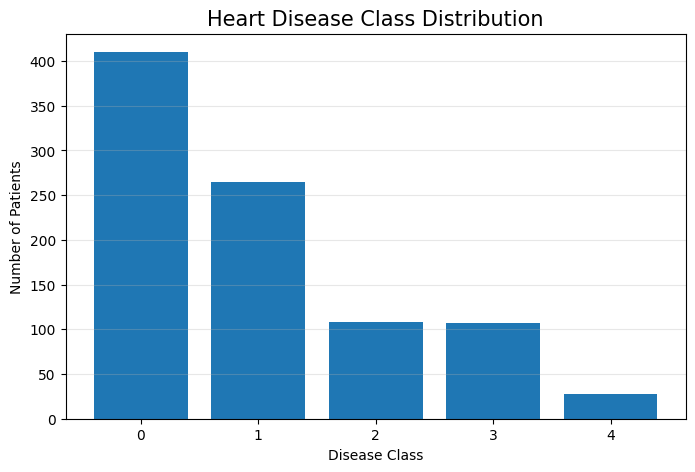


Training samples: 734
Testing samples : 184

Training Random Forest...
Training completed!


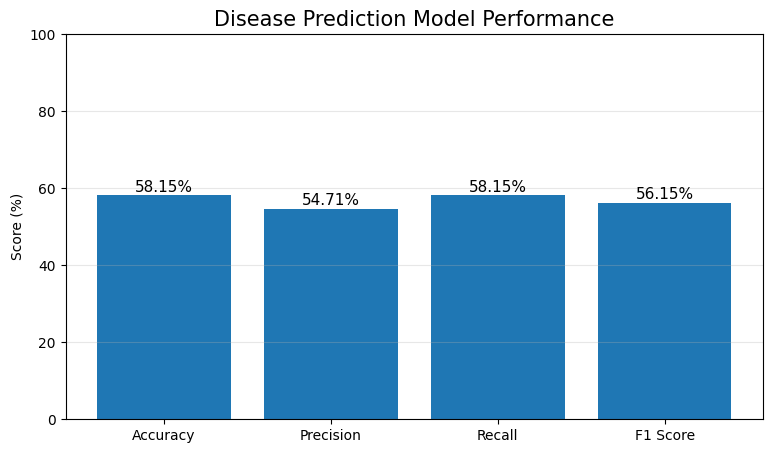

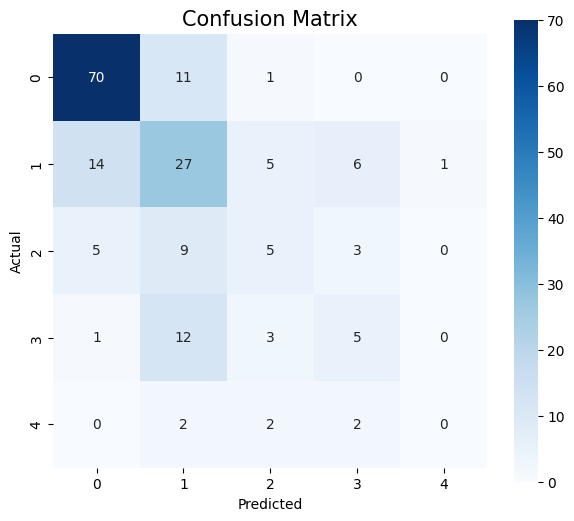

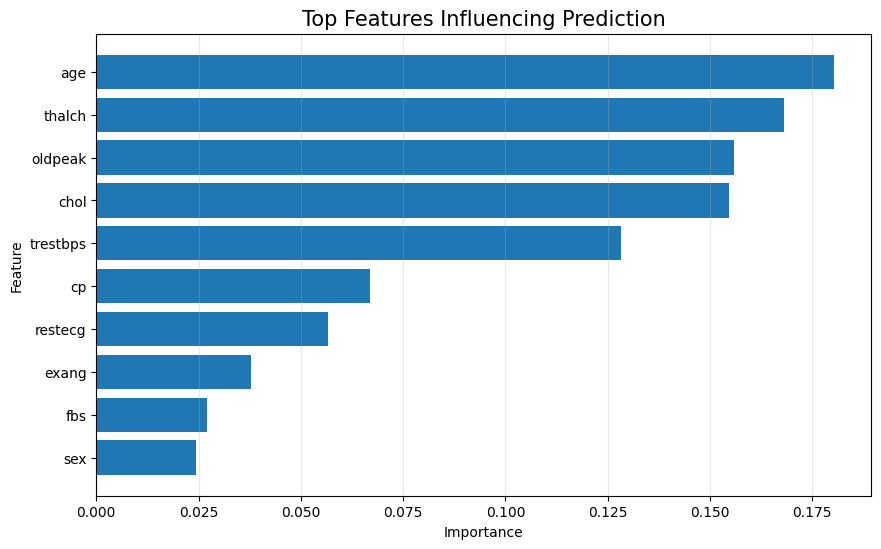

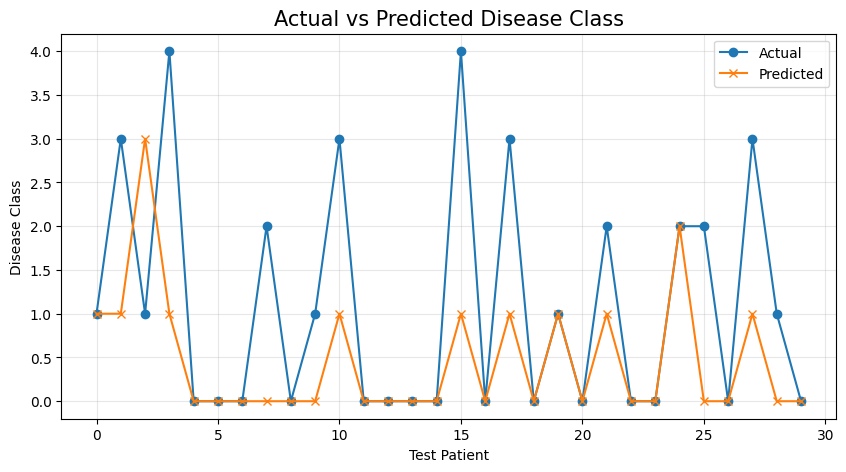


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        82
           1       0.44      0.51      0.47        53
           2       0.31      0.23      0.26        22
           3       0.31      0.24      0.27        21
           4       0.00      0.00      0.00         6

    accuracy                           0.58       184
   macro avg       0.37      0.37      0.36       184
weighted avg       0.55      0.58      0.56       184


SAMPLE PATIENT PREDICTION
Predicted class: 1


╔══════════════════════════════════════════════╗
║       CODEALPHA TASK 4 DASHBOARD             ║
╠══════════════════════════════════════════════╣
║ Dataset          : Heart Disease             ║
║ Model            : Random Forest             ║
║ Accuracy         :  58.15%                  ║
║ Precision        :  54.71%                  ║
║ Recall           :  58.15%                  ║
║ F1 Score         :  56.15%                  ║
║ T

In [ ]:
# ============================================================
# CODEALPHA TASK 4
# DISEASE PREDICTION FROM MEDICAL DATA
# HEART DISEASE - RANDOM FOREST
# COMPLETE DASHBOARD + VISUALIZATIONS
# ============================================================

!pip install -q pandas numpy matplotlib seaborn scikit-learn

import os
import glob
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. FIND UPLOADED ZIP
# ============================================================

zip_files = glob.glob("/content/*.zip")

print("ZIP files found:")

for f in zip_files:
    print(f)

if len(zip_files) == 0:
    raise Exception("No ZIP file found in /content.")

zip_file = zip_files[0]

# ============================================================
# 2. EXTRACT ZIP
# ============================================================

extract_path = "/content/heart_disease"

os.makedirs(
    extract_path,
    exist_ok=True
)

with zipfile.ZipFile(
    zip_file,
    "r"
) as z:

    z.extractall(
        extract_path
    )

print("\nDataset extracted successfully!")


# ============================================================
# 3. FIND CSV FILE
# ============================================================

csv_files = glob.glob(
    extract_path + "/**/*.csv",
    recursive=True
)

print("\nCSV files found:")

for f in csv_files:
    print(f)

if len(csv_files) == 0:
    raise Exception(
        "No CSV file found inside the ZIP."
    )

# Select CSV
csv_file = csv_files[0]

print("\nUsing:")
print(csv_file)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    csv_file,
    low_memory=False
)

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())


# ============================================================
# 5. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("\nColumns:")
print(list(df.columns))


# ============================================================
# 6. FIND TARGET COLUMN
# ============================================================

possible_targets = [
    "target",
    "label",
    "heartdisease",
    "heart_disease",
    "disease",
    "output",
    "condition",
    "num"
]

target = None

for col in possible_targets:

    if col in df.columns:
        target = col
        break


# If target is not found, use last column
if target is None:

    target = df.columns[-1]

print("\nTarget column:")
print(target)


# ============================================================
# 7. REMOVE COMPLETELY EMPTY COLUMNS
# ============================================================

df = df.dropna(
    axis=1,
    how="all"
)


# ============================================================
# 8. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(
    columns=[target]
).copy()

y = df[target].copy()


# ============================================================
# 9. CLEAN TARGET
# ============================================================

# Convert numeric target if possible

y_numeric = pd.to_numeric(
    y,
    errors="coerce"
)

if y_numeric.notna().sum() == len(y):

    y = y_numeric

else:

    y = y.astype(str).str.strip()

    encoder_y = LabelEncoder()

    y = encoder_y.fit_transform(y)


# Remove invalid target rows

valid_rows = pd.Series(y).notna().values

X = X.loc[valid_rows].reset_index(
    drop=True
)

y = np.asarray(y)[valid_rows]


# ============================================================
# 10. CONVERT FEATURES
# ============================================================

for col in X.columns:

    # Try converting object columns to numeric
    converted = pd.to_numeric(
        X[col],
        errors="coerce"
    )

    # If most values can become numeric,
    # keep numeric version
    if converted.notna().mean() >= 0.7:

        X[col] = converted


# ============================================================
# 11. ENCODE CATEGORICAL FEATURES
# ============================================================

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nCategorical columns:")

if len(categorical_columns) == 0:
    print("None")
else:
    print(categorical_columns)


for col in categorical_columns:

    X[col] = X[col].astype(str)

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col]
    )


# ============================================================
# 12. CONVERT EVERYTHING TO NUMERIC
# ============================================================

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)


# ============================================================
# 13. REMOVE COLUMNS THAT ARE COMPLETELY EMPTY
# ============================================================

X = X.dropna(
    axis=1,
    how="all"
)


# ============================================================
# 14. FILL MISSING VALUES
# ============================================================

imputer = SimpleImputer(
    strategy="median"
)

X = imputer.fit_transform(
    X
)


# ============================================================
# 15. FINAL DATA INFORMATION
# ============================================================

print("\n======================================")
print("DATA PREPARATION")
print("======================================")

print(
    "Samples:",
    X.shape[0]
)

print(
    "Features:",
    X.shape[1]
)

print(
    "Target classes:",
    np.unique(y)
)


# ============================================================
# DASHBOARD VISUALIZATION 1
# TARGET DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 5)
)

unique, counts = np.unique(
    y,
    return_counts=True
)

plt.bar(
    [str(x) for x in unique],
    counts
)

plt.title(
    "Heart Disease Class Distribution",
    fontsize=15
)

plt.xlabel(
    "Disease Class"
)

plt.ylabel(
    "Number of Patients"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 16. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 17. RANDOM FOREST MODEL
# ============================================================

model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)


# ============================================================
# 18. TRAIN MODEL
# ============================================================

print("\nTraining Random Forest...")

model.fit(
    X_train,
    y_train
)

print(
    "Training completed!"
)


# ============================================================
# 19. PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test
)


# ============================================================
# 20. METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# DASHBOARD VISUALIZATION 2
# MODEL PERFORMANCE
# ============================================================

metrics = {
    "Accuracy": accuracy * 100,
    "Precision": precision * 100,
    "Recall": recall * 100,
    "F1 Score": f1 * 100
}

plt.figure(
    figsize=(9, 5)
)

bars = plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.title(
    "Disease Prediction Model Performance",
    fontsize=15
)

plt.ylabel(
    "Score (%)"
)

plt.ylim(
    0,
    100
)

for bar, value in zip(
    bars,
    metrics.values()
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=11
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 21. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


# ============================================================
# DASHBOARD VISUALIZATION 3
# CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    square=True
)

plt.title(
    "Confusion Matrix",
    fontsize=15
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()


# ============================================================
# 22. FEATURE IMPORTANCE
# ============================================================

feature_names = df.drop(
    columns=[target]
).columns.tolist()

# Keep only the number of columns used by X
feature_names = feature_names[
    :len(model.feature_importances_)
]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)


# ============================================================
# DASHBOARD VISUALIZATION 4
# FEATURE IMPORTANCE
# ============================================================

top_features = importance.head(
    min(10, len(importance))
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title(
    "Top Features Influencing Prediction",
    fontsize=15
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()


# ============================================================
# 23. ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})


# ============================================================
# DASHBOARD VISUALIZATION 5
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(10, 5)
)

sample_size = min(
    30,
    len(comparison)
)

plt.plot(
    range(sample_size),
    comparison["Actual"].iloc[:sample_size],
    marker="o",
    label="Actual"
)

plt.plot(
    range(sample_size),
    comparison["Predicted"].iloc[:sample_size],
    marker="x",
    label="Predicted"
)

plt.title(
    "Actual vs Predicted Disease Class",
    fontsize=15
)

plt.xlabel(
    "Test Patient"
)

plt.ylabel(
    "Disease Class"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 24. CLASSIFICATION REPORT
# ============================================================

print("\n======================================")
print("CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 25. PATIENT PREDICTION EXAMPLE
# ============================================================

sample_patient = X_test[0].reshape(
    1, -1
)

prediction = model.predict(
    sample_patient
)[0]


print("\n======================================")
print("SAMPLE PATIENT PREDICTION")
print("======================================")

print(
    "Predicted class:",
    prediction
)


# ============================================================
# 26. FINAL DASHBOARD
# ============================================================

print("\n")
print("╔══════════════════════════════════════════════╗")
print("║       CODEALPHA TASK 4 DASHBOARD             ║")
print("╠══════════════════════════════════════════════╣")
print(f"║ Dataset          : Heart Disease             ║")
print(f"║ Model            : Random Forest             ║")
print(f"║ Accuracy         : {accuracy*100:6.2f}%                  ║")
print(f"║ Precision        : {precision*100:6.2f}%                  ║")
print(f"║ Recall           : {recall*100:6.2f}%                  ║")
print(f"║ F1 Score         : {f1*100:6.2f}%                  ║")
print(f"║ Training Samples : {len(X_train):6d}                   ║")
print(f"║ Testing Samples  : {len(X_test):6d}                   ║")
print("╚══════════════════════════════════════════════╝")


# ============================================================
# 27. SAVE MODEL
# ============================================================

import joblib

joblib.dump(
    model,
    "/content/heart_disease_model.pkl"
)

print("\nModel saved successfully!")

print(
    "/content/heart_disease_model.pkl"
)


# ============================================================
# 28. SAVE FEATURE IMPORTANCE
# ============================================================

importance.to_csv(
    "/content/feature_importance.csv",
    index=False
)

print(
    "Feature importance saved successfully!"
)